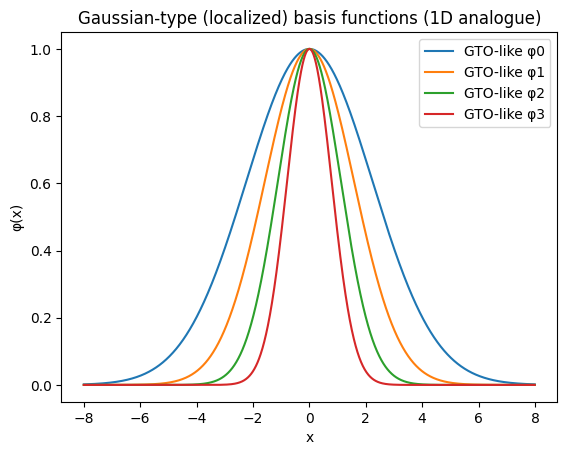

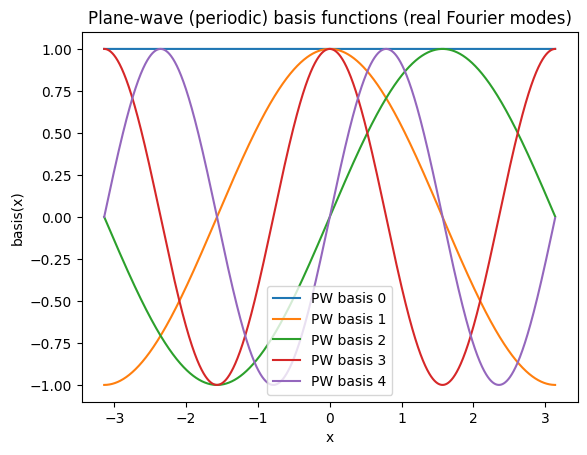

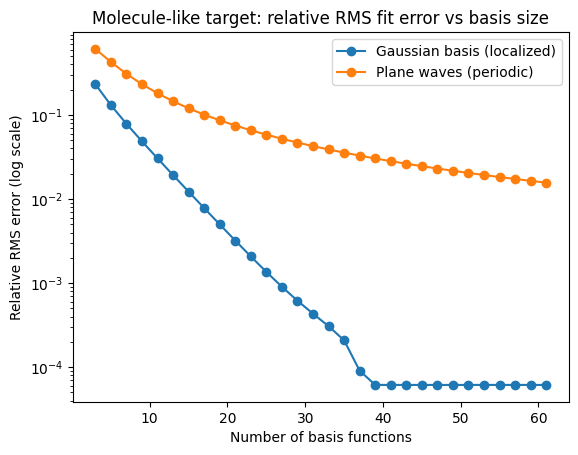

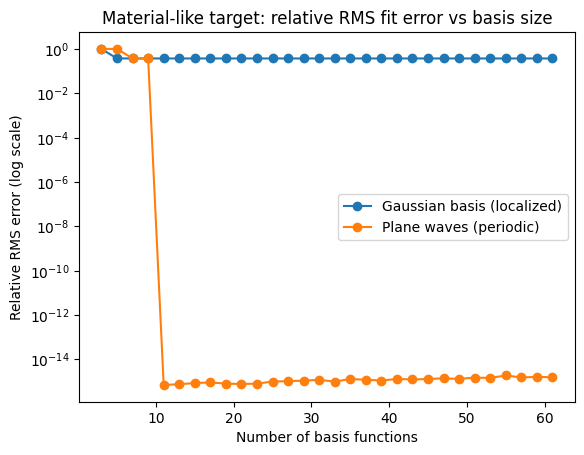

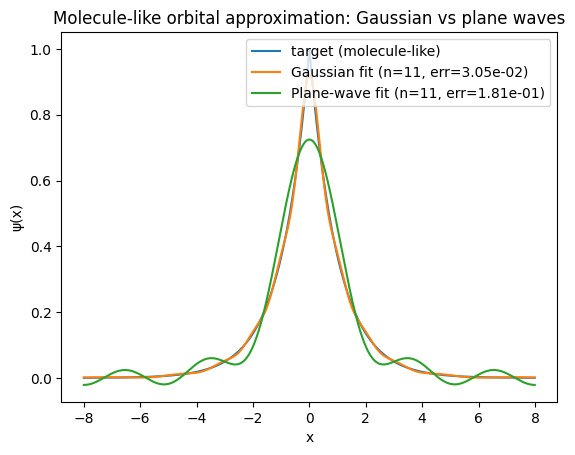

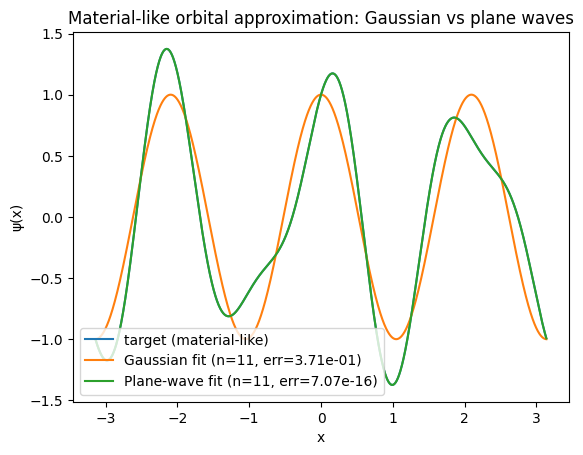

Reconstruction errors at n_show = 11
 Molecule-like: Gaussian err = 0.03050528184470163 Plane-wave err = 0.1814950538161553
 Material-like: Gaussian err = 0.3713906763592792 Plane-wave err = 7.065122323599934e-16


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Define "basis functions"
# -----------------------------
def gaussian_basis(x, n, alpha0=0.15, ratio=1.6, center=0.0):
    """
    n Gaussian-type basis functions (1D analogue of atom-centered GTOs):
      phi_j(x) = exp(-alpha_j (x-center)^2), with alpha_j in a geometric progression.
    Returns design matrix A with shape (len(x), n).
    """
    alphas = alpha0 * (ratio ** np.arange(n))
    A = np.exp(-np.outer((x - center) ** 2, alphas))
    return A

def plane_wave_basis_real(x, n, L):
    """
    n real plane-wave basis functions on domain length L (periodic):
      [1, cos(2πx/L), sin(2πx/L), cos(4πx/L), sin(4πx/L), ...]
    n must be odd: n = 1 + 2K.
    Returns design matrix A with shape (len(x), n).
    """
    if n % 2 == 0:
        raise ValueError("For this simple real Fourier basis, n must be odd: n = 1 + 2K.")
    K = (n - 1) // 2
    cols = [np.ones_like(x)]
    for k in range(1, K + 1):
        cols.append(np.cos(2 * np.pi * k * x / L))
        cols.append(np.sin(2 * np.pi * k * x / L))
    A = np.column_stack(cols)
    return A

def fit_and_error(A, y):
    """
    Least-squares fit y ≈ A c, returns y_hat and relative RMS error.
    """
    c, *_ = np.linalg.lstsq(A, y, rcond=None)
    y_hat = A @ c
    rel_rms = np.sqrt(np.mean((y - y_hat) ** 2)) / np.sqrt(np.mean(y ** 2))
    return y_hat, rel_rms

# -----------------------------
# 2) Targets: "molecule" vs "material"
# -----------------------------
# Molecule-like: localized orbital in a large box (supercell picture)
L_mol = 16.0
x_mol = np.linspace(-L_mol/2, L_mol/2, 2000, endpoint=False)

# A smooth, localized "orbital-like" function (finite support effectively)
# (Chosen so it dies off near boundaries, making periodic extension less problematic.)
psi_mol = np.exp(-np.abs(x_mol))  # 1D Slater-like decay (not a Gaussian)

# Material-like: periodic Bloch-like (purely periodic signal)
L_sol = 2 * np.pi
x_sol = np.linspace(-np.pi, np.pi, 2000, endpoint=False)
psi_sol = np.cos(3 * x_sol) + 0.4 * np.sin(5 * x_sol)

# -----------------------------
# 3) Visualize a few basis functions (shape intuition)
# -----------------------------
# Gaussian basis snapshots
A_g_demo = gaussian_basis(x_mol, n=4, alpha0=0.1, ratio=2.0, center=0.0)
plt.figure()
for j in range(A_g_demo.shape[1]):
    plt.plot(x_mol, A_g_demo[:, j], label=f"GTO-like φ{j}")
plt.title("Gaussian-type (localized) basis functions (1D analogue)")
plt.xlabel("x")
plt.ylabel("φ(x)")
plt.legend()
plt.show()

# Plane-wave basis snapshots
A_pw_demo = plane_wave_basis_real(x_sol, n=5, L=L_sol)  # 1 + cos/sin for k=1,2
plt.figure()
for j in range(A_pw_demo.shape[1]):
    plt.plot(x_sol, A_pw_demo[:, j], label=f"PW basis {j}")
plt.title("Plane-wave (periodic) basis functions (real Fourier modes)")
plt.xlabel("x")
plt.ylabel("basis(x)")
plt.legend()
plt.show()

# -----------------------------
# 4) Compare approximation quality vs basis size
# -----------------------------
Ns = list(range(3, 62, 2))  # odd sizes: 3,5,...,61 so plane-wave basis fits n=1+2K

err_mol_g, err_mol_pw = [], []
err_sol_g, err_sol_pw = [], []

for n in Ns:
    # molecule: Gaussian basis
    A_g = gaussian_basis(x_mol, n=n, alpha0=0.10, ratio=1.35, center=0.0)
    _, e_g = fit_and_error(A_g, psi_mol)
    err_mol_g.append(e_g)

    # molecule: plane waves
    A_pw = plane_wave_basis_real(x_mol, n=n, L=L_mol)
    _, e_pw = fit_and_error(A_pw, psi_mol)
    err_mol_pw.append(e_pw)

    # solid: Gaussian basis (still centered at 0 -> intentionally "molecule-style" localized basis)
    A_gs = gaussian_basis(x_sol, n=n, alpha0=0.10, ratio=1.35, center=0.0)
    _, e_gs = fit_and_error(A_gs, psi_sol)
    err_sol_g.append(e_gs)

    # solid: plane waves
    A_pws = plane_wave_basis_real(x_sol, n=n, L=L_sol)
    _, e_pws = fit_and_error(A_pws, psi_sol)
    err_sol_pw.append(e_pws)

# Error curves: molecule
plt.figure()
plt.semilogy(Ns, err_mol_g, marker="o", label="Gaussian basis (localized)")
plt.semilogy(Ns, err_mol_pw, marker="o", label="Plane waves (periodic)")
plt.title("Molecule-like target: relative RMS fit error vs basis size")
plt.xlabel("Number of basis functions")
plt.ylabel("Relative RMS error (log scale)")
plt.legend()
plt.show()

# Error curves: material
plt.figure()
plt.semilogy(Ns, err_sol_g, marker="o", label="Gaussian basis (localized)")
plt.semilogy(Ns, err_sol_pw, marker="o", label="Plane waves (periodic)")
plt.title("Material-like target: relative RMS fit error vs basis size")
plt.xlabel("Number of basis functions")
plt.ylabel("Relative RMS error (log scale)")
plt.legend()
plt.show()

# -----------------------------
# 5) Show reconstructions at a fixed basis size
# -----------------------------
n_show = 11  # 1+2K with K=5; should represent psi_sol exactly (or nearly) for our chosen harmonics.

# Molecule reconstructions
A_g = gaussian_basis(x_mol, n=n_show, alpha0=0.10, ratio=1.35, center=0.0)
psi_mol_g_hat, e_mol_g = fit_and_error(A_g, psi_mol)

A_pw = plane_wave_basis_real(x_mol, n=n_show, L=L_mol)
psi_mol_pw_hat, e_mol_pw = fit_and_error(A_pw, psi_mol)

plt.figure()
plt.plot(x_mol, psi_mol, label="target (molecule-like)")
plt.plot(x_mol, psi_mol_g_hat, label=f"Gaussian fit (n={n_show}, err={e_mol_g:.2e})")
plt.plot(x_mol, psi_mol_pw_hat, label=f"Plane-wave fit (n={n_show}, err={e_mol_pw:.2e})")
plt.title("Molecule-like orbital approximation: Gaussian vs plane waves")
plt.xlabel("x")
plt.ylabel("ψ(x)")
plt.legend()
plt.show()

# Material reconstructions
A_gs = gaussian_basis(x_sol, n=n_show, alpha0=0.10, ratio=1.35, center=0.0)
psi_sol_g_hat, e_sol_g = fit_and_error(A_gs, psi_sol)

A_pws = plane_wave_basis_real(x_sol, n=n_show, L=L_sol)
psi_sol_pw_hat, e_sol_pw = fit_and_error(A_pws, psi_sol)

plt.figure()
plt.plot(x_sol, psi_sol, label="target (material-like)")
plt.plot(x_sol, psi_sol_g_hat, label=f"Gaussian fit (n={n_show}, err={e_sol_g:.2e})")
plt.plot(x_sol, psi_sol_pw_hat, label=f"Plane-wave fit (n={n_show}, err={e_sol_pw:.2e})")
plt.title("Material-like orbital approximation: Gaussian vs plane waves")
plt.xlabel("x")
plt.ylabel("ψ(x)")
plt.legend()
plt.show()

# Summarize numeric takeaways (no hand-waving)
print("Reconstruction errors at n_show =", n_show)
print(" Molecule-like: Gaussian err =", e_mol_g, "Plane-wave err =", e_mol_pw)
print(" Material-like: Gaussian err =", e_sol_g, "Plane-wave err =", e_sol_pw)


In [5]:
import sys
import numpy as np
import matplotlib.pyplot as plt

from pyscf import gto, scf
from pyscf.dft import numint

In [ ]:
# -------------------------
# Utilities
# -------------------------
def read_xyz(path):
    """
    Minimal XYZ reader.
    Returns a PySCF atom string and a list of (symbol, (x,y,z)) in Angstrom.
    """
    with open(path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    n = int(lines[0])
    geom = []
    for ln in lines[2:2+n]:
        parts = ln.split()
        sym = parts[0]
        x, y, z = map(float, parts[1:4])
        geom.append((sym, (x, y, z)))
    atom_str = "\n".join([f"{s} {r[0]} {r[1]} {r[2]}" for s, r in geom])
    return atom_str, geom

def make_grid_cube(center_bohr, L_bohr=16.0, n=28):
    """
    Build a uniform cubic grid of side length L_bohr, centered at center_bohr.
    Returns coords (ngrids,3), and grid axes.
    """
    half = L_bohr / 2
    xs = np.linspace(center_bohr[0]-half, center_bohr[0]+half, n, endpoint=False)
    ys = np.linspace(center_bohr[1]-half, center_bohr[1]+half, n, endpoint=False)
    zs = np.linspace(center_bohr[2]-half, center_bohr[2]+half, n, endpoint=False)
    X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")
    coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    return coords, xs, ys, zs

def plane_wave_G_vectors(Ecut, L_bohr, nmax_cap=30):
    """
    Build reciprocal vectors G = 2π/L * n with n in Z^3,
    keeping those with |G|^2/2 <= Ecut (Hartree units).
    nmax_cap prevents runaway in case of tiny L or huge Ecut.
    """
    # |G|^2/2 <= Ecut => |n|^2 <= (Ecut) * (L/π)^2
    nmax = int(np.floor(np.sqrt(Ecut) * (L_bohr / np.pi))) + 1
    nmax = min(nmax, nmax_cap)

    twopi_over_L = 2.0 * np.pi / L_bohr
    Gs = []
    for nx in range(-nmax, nmax+1):
        for ny in range(-nmax, nmax+1):
            for nz in range(-nmax, nmax+1):
                nvec = np.array([nx, ny, nz], dtype=float)
                G = twopi_over_L * nvec
                if 0.5 * np.dot(G, G) <= Ecut + 1e-12:
                    Gs.append(G)
    Gs = np.array(Gs, dtype=float)
    return Gs

def fit_plane_waves(coords, psi, Gs):
    """
    Fit psi(r) ~ sum_G c_G exp(i G·r) by least squares.
    Returns psi_hat and relative RMS error.
    """
    phase = coords @ Gs.T  # (ngrids, NG)
    A = np.exp(1j * phase) # complex design matrix
    c, *_ = np.linalg.lstsq(A, psi, rcond=None)
    psi_hat = A @ c
    rel_rms = np.sqrt(np.mean(np.abs(psi - psi_hat)**2)) / np.sqrt(np.mean(np.abs(psi)**2))
    return psi_hat, rel_rms

# -------------------------
# Main
# -------------------------
if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python compare_mo_gaussian_vs_planewave.py molecule.xyz")
        sys.exit(1)

    xyz_path = sys.argv[1]

    # ---- Load molecule ----
    atom_str, geom = read_xyz(xyz_path)

    mol = gto.Mole()
    mol.atom = atom_str
    mol.unit = "Angstrom"
    mol.basis = "cc-pVDZ"   # try: "sto-3g", "6-31g", "cc-pVTZ", "def2-SVP", ...
    mol.spin = 0
    mol.charge = 0
    mol.build()

    # ---- SCF ----
    mf = scf.RHF(mol)
    mf.conv_tol = 1e-10
    e = mf.kernel()
    print("SCF energy (Hartree):", e)
    print("NAO (Gaussian basis functions):", mol.nao_nr())

    # Pick an MO: HOMO for closed-shell RHF is index (nocc-1)
    nocc = mol.nelectron // 2
    mo_idx = nocc - 1
    C = mf.mo_coeff[:, mo_idx]  # (nao,)
    print("Using MO index:", mo_idx, "(HOMO)")

    # ---- Build a cubic supercell grid (in Bohr) ----
    # Center at nuclear center-of-mass-ish: just average coords here
    coords_ang = np.array([r for _, r in geom], dtype=float)
    center_ang = coords_ang.mean(axis=0)
    # Convert Angstrom -> Bohr
    ang2bohr = 1.8897259886
    center_bohr = center_ang * ang2bohr

    L_bohr = 18.0   # enlarge if your orbital touches the boundary
    ngrid = 30      # 30^3 = 27000 points
    coords, xs, ys, zs = make_grid_cube(center_bohr, L_bohr=L_bohr, n=ngrid)
    print("Grid points:", coords.shape[0], "Box size (Bohr):", L_bohr)

    # ---- Evaluate AO and MO on grid ----
    ao = numint.eval_ao(mol, coords, deriv=0)  # (ngrids, nao)
    psi = ao @ C                               # (ngrids,)
    # make sure it's complex for plane-wave fitting code
    psi = psi.astype(np.complex128)

    # ---- Plane-wave fits for increasing Ecut ----
    Ecuts = [1, 2, 4, 6, 8, 10, 15, 20, 30, 40]  # Hartree
    Ns = []
    errs = []

    for Ecut in Ecuts:
        Gs = plane_wave_G_vectors(Ecut, L_bohr=L_bohr, nmax_cap=40)
        psi_hat, rel_rms = fit_plane_waves(coords, psi, Gs)
        Ns.append(len(Gs))
        errs.append(rel_rms)
        print(f"Ecut={Ecut:>3} Ha | Npw={len(Gs):>6} | relRMS={rel_rms:.3e}")

    # ---- Plot error vs Npw ----
    plt.figure()
    plt.semilogy(Ns, errs, marker="o")
    plt.title("Plane-wave fit error for a real molecular orbital (PySCF target)")
    plt.xlabel("Number of plane waves (Npw)")
    plt.ylabel("Relative RMS error (log scale)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

    # ---- Visualize a 2D slice through the box (z ~ mid) for one cutoff ----
    # Choose a moderate cutoff to visualize
    Ecut_show = 20
    Gs = plane_wave_G_vectors(Ecut_show, L_bohr=L_bohr, nmax_cap=40)
    psi_hat, rel_rms = fit_plane_waves(coords, psi, Gs)

    # Reshape to 3D grid and take mid z-slice
    psi3 = psi.reshape(ngrid, ngrid, ngrid)
    hat3 = psi_hat.reshape(ngrid, ngrid, ngrid)
    kz = ngrid // 2

    plt.figure()
    plt.imshow(np.real(psi3[:, :, kz]), origin="lower")
    plt.title("Target MO slice (real part)")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.imshow(np.real(hat3[:, :, kz]), origin="lower")
    plt.title(f"Plane-wave fit slice (real part), Ecut={Ecut_show} Ha, relRMS={rel_rms:.2e}")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.imshow(np.real(psi3[:, :, kz] - hat3[:, :, kz]), origin="lower")
    plt.title("Slice error (target - fit), real part")
    plt.colorbar()
    plt.show()
